In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, pickle

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)
# tf.config.run_functions_eagerly(True)

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm
from icecream import ic

from msfm.grid_pipeline import GridPipeline
from msfm.utils import logger, files, scales, power_spectra, parameters

from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization, configuration
from deep_lss.nets.mlp import MultiLayerPerceptron

from msi.utils import preprocessing, dataset, input_output

2025-04-03 02:48:06.069835: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-03 02:48:06.069864: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-03 02:48:06.070673: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-03 02:48:06.075967: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
ls  /global/u1/j/jbucko/y3-deep-lss/deep_lss/nets

custom_layers.py     legacy/        __pycache__/        transformer.py
gaussian_mixture.py  mlp.py         regression_head.py
__init__.py          one_d_conv.py  resnet.py


### v10

In [4]:
# msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v10/linear_bias"
# mocks = ["Buzzard", "Cardinal"]
# # # mocks = ["Buzzard", "Buzzard_mocked_DNF", "Cardinal"]

# # msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias_octant.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/v11desy3/v10/linear_bias_octant"
# # mocks = ["MICE", "Euclid"]

# # for the white noise level
# dlss_conf = configuration.load_deep_lss_config("/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/dlss_config.yaml")
# # dlss_conf = configuration.load_deep_lss_config("/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/dlss_high_noise.yaml")

# # dlss_conf = configuration.load_deep_lss_config("/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/noise_levels/dlss_1%.yaml")
# # dlss_conf = configuration.load_deep_lss_config("/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/noise_levels/dlss_10%.yaml")
# # dlss_conf = configuration.load_deep_lss_config("/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/noise_levels/dlss_naive.yaml")

# # dlss_conf = configuration.load_deep_lss_config(
# #     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_28mpc.yaml"
# # )


# label = "16mpc"
# # label = "20mpc"
# # label = "24mpc"
# # label = "28mpc"
# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_{label}.yaml"
# )
# # label += "_octant"
# # label += "_flock"

# out_dir = "/pscratch/sd/a/athomsen/run_files/v10"
# # out_dir = "/pscratch/sd/a/athomsen/run_files/v10/octant"
# # label = "default,new"
# # label = "default,from_maps"
# # label = "default,1%noise"
# # label = "default,10%noise"
# # label = "default,naive_noise"

# # label = "no_ell_in_bins_[:8]"
# # label = "no_ell_in_bins_[:2]"
# # label = "no_ell_in_bins_[-8:]"
# # label = "high_noise"
# # label = "no_noise"
# # label = "legacy,fixed_binning"
# # label = "legacy,l_min=0"
# # label = "legacy,corrected,l_min"
# # label = "euclid"

# # label = "z_consistency,auto"
# # [26, 30, 33, 35]
# # bin_index = 35
# # label = f"z_consistency,{bin_index}"

# # l_max = [267, 390, 510, 610]
# # label = "hard_cut"

# # label = "smoothing_big,noise_small"
# # theta_fwhm = [22.1, 15.1, 11.2, 9.4, 65.1, 44.5, 34.1, 28.5]
# # white_noise_sigma = [2.3090e-04, 3.0336e-04, 4.1867e-04, 1.0056e-03, 5.0699e-01, 2.1057e-01, 1.5098e-01, 1.3614e-01]

# # label = "smoothing_small,noise_big"
# # theta_fwhm = 0.707 * np.array([22.1, 15.1, 11.2, 9.4, 65.1, 44.5, 34.1, 28.5])
# # white_noise_sigma = [7.3134e-04, 9.7611e-04, 1.2943e-03, 2.2269e-03, 1.6128e+00, 6.6656e-01, 4.6794e-01, 4.3220e-01]

In [5]:
# with_lensing = True
# with_clustering = False
# with_cross_z = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# mocks = []

In [6]:
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "bg", "n_bg"]

In [7]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# mocks = []

### v11

In [8]:
# msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v11/extended.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v11/extended"
# mocks = ["Buzzard", "Cardinal"]

# # dlss_conf = configuration.load_deep_lss_config(
# #     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_28mpc.yaml"
# # )


# # label = "16mpc"
# # label = "20mpc"
# # label = "24mpc"
# label = "28mpc"
# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_{label}.yaml"
# )
# # label += "_octant"

# out_dir = "/pscratch/sd/a/athomsen/run_files/v11"
# # out_dir += "/octant"

In [9]:
# with_lensing = True
# with_clustering = False
# with_cross_z = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# # params = ["Om", "s8"]
# mocks = []

In [10]:
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

In [11]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# mocks = []

In [12]:
# label += "_" + str(params).replace(" ", "").replace("'", "")

### v12

In [13]:
# msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v12/nonlinear.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v12/nonlinear"
# mocks = ["Buzzard", "Cardinal"]

# # dlss_conf = configuration.load_deep_lss_config(
# #     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_28mpc.yaml"
# # )

# # label = "16mpc"
# label = "20mpc"
# # label = "24mpc"
# # label = "28mpc"
# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v12/clustering/smoothing_fwhm/dlss_{label}.yaml"
# )
# # label += "_octant"
# # label += "_no_cross_z"

# out_dir = "/pscratch/sd/a/athomsen/run_files/v12"
# # out_dir += "/octant"

In [14]:
# with_lensing = True
# with_clustering = False
# with_cross_z = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# mocks = []

In [15]:
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4", "qbg1", "qbg2", "qbg3", "qbg4"]

In [16]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# mocks = []

### v13

In [17]:
# msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v13/extended.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v13/extended"
msfm_conf = files.load_config("/global/homes/j/jbucko/multiprobe-simulation-forward-model/configs/v13/extended.yaml")
# base_dir = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0"
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v13/extended"
mocks = ["Buzzard", "Cardinal"]

# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_28mpc.yaml"
# )

# # label = "16mpc"
# # label = "20mpc"
# # label = "24mpc"
# # label = "28mpc"
# label = "32mpc"
# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v13/clustering/smoothing_fwhm/dlss_{label}.yaml"
# )

label = "8mpc"
# label = "12mpc"
dlss_conf = configuration.load_deep_lss_config(
    f"/global/homes/j/jbucko/y3-deep-lss/configs/v13/lensing/smoothing_fwhm/dlss_{label}.yaml"
)

# label += "_octant"

# out_dir = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0"
out_dir = "/pscratch/sd/a/athomsen/run_files/v13"
# out_dir += "/octant"

25-04-03 02:58:03 configuratio INF   Loaded the config 


In [18]:
with_lensing = True
with_clustering = False
with_cross_z = True
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
mocks = []

In [19]:
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

In [20]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# mocks = []

# constants

In [21]:
batch_size = 2**12
# batch_size = 2**10
shuffle_buffer = 4*batch_size
apply_log = True
standardize = False

cosine_decay = False
# n_steps = 100_000
n_steps = 200_000

out_dir = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log={apply_log},cosine={cosine_decay},steps={n_steps}")

if label is not None:
    out_dir = os.path.join(out_dir, label)
os.makedirs(out_dir, exist_ok=True)

In [22]:
print(out_dir)

/pscratch/sd/a/athomsen/run_files/v13/cls/mutual_info/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc


# debug

In [9]:
# obs_label = "Buzzard"

# # single Buzzard, not flock

# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# # buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_from_g1g2.h5"
# # buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_weights_with_balrog_e12_shear_with_buzzard_e1e2.h5"
# # buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_e1e2_from_DES_g1g2_from_Buzzard.h5"
# # buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_e1e2_from_DES_g1g2_from_Buzzard_with_weights.h5"
# buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_shape_noise_fw_g1g2_Buzzard.h5"

# with h5py.File(buzzard_lensing_file, "r") as f_in:
#     gamma1 = []
#     gamma2 = []
#     for i in range(1,5):
#         gamma1.append(f_in[f"metacal/raw_gamma1_bin{i}"])
#         gamma2.append(f_in[f"metacal/raw_gamma2_bin{i}"])
#     gamma1 = np.stack(gamma1, axis=-1)
#     gamma2 = np.stack(gamma2, axis=-1)
    
#     wl_map = np.stack([gamma1, gamma2], axis=-1)
        

In [10]:
# hp.mollview(wl_map[:,0,0], nest=True)
# hp.mollview(wl_map[:,0,1], nest=True)

In [11]:
# buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_shape_noise_fw_g1g2_Buzzard.h5"

# with h5py.File(buzzard_lensing_file, "r") as f_in:
#     print(f_in["metacal"].keys())

# white noise dset

25-04-03 02:58:17 configuratio INF   Loaded the config 
25-04-03 02:58:17 preprocessin INF   Using theta_fwhm = [29.5, 20.1, 15.0, 12.6, 113.9, 77.8, 59.6, 49.9] from the dlss config 
25-04-03 02:58:17 preprocessin INF   Using white_noise_sigma = [0.00030275, 0.00040448, 0.00048782, 0.00052049, 0.78257, 0.31326, 0.23333, 0.21634] from the dlss config 
25-04-03 02:58:17 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  94.82001756
 138.81748072 181.20805369 216.43286573] from the dlss config 
25-04-03 02:58:17 preprocessin INF   Using l_mins = [0. 0. 0. 0. 0. 0. 0. 0.] by default (no smoothing) 
25-04-03 02:58:17 preprocessin INF   Using n_bins = 33 from the msfm config 
25-04-03 02:58:17 preprocessin INF   Loading the pre-binned Cls 
25-04-03 02:58:17 input_output INF   Loading summaries from /pscratch/sd/a/athomsen/v11desy3/v13/extended 
25-04-03 02:58:17 input_output INF   Array shapes: 
25-04-03 02:58:17 input_output INF   fiducial/i_example = (

2025-04-03 02:58:47.468984: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79077 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:41:00.0, compute capability: 8.0


25-04-03 02:58:48 preprocessin INF   Taking the logarithm of the absolute values. 
25-04-03 02:58:48 preprocessin INF   Taking the logarithm of the absolute values. 
25-04-03 02:58:50 preprocessin INF   Taking the logarithm of the absolute values. 


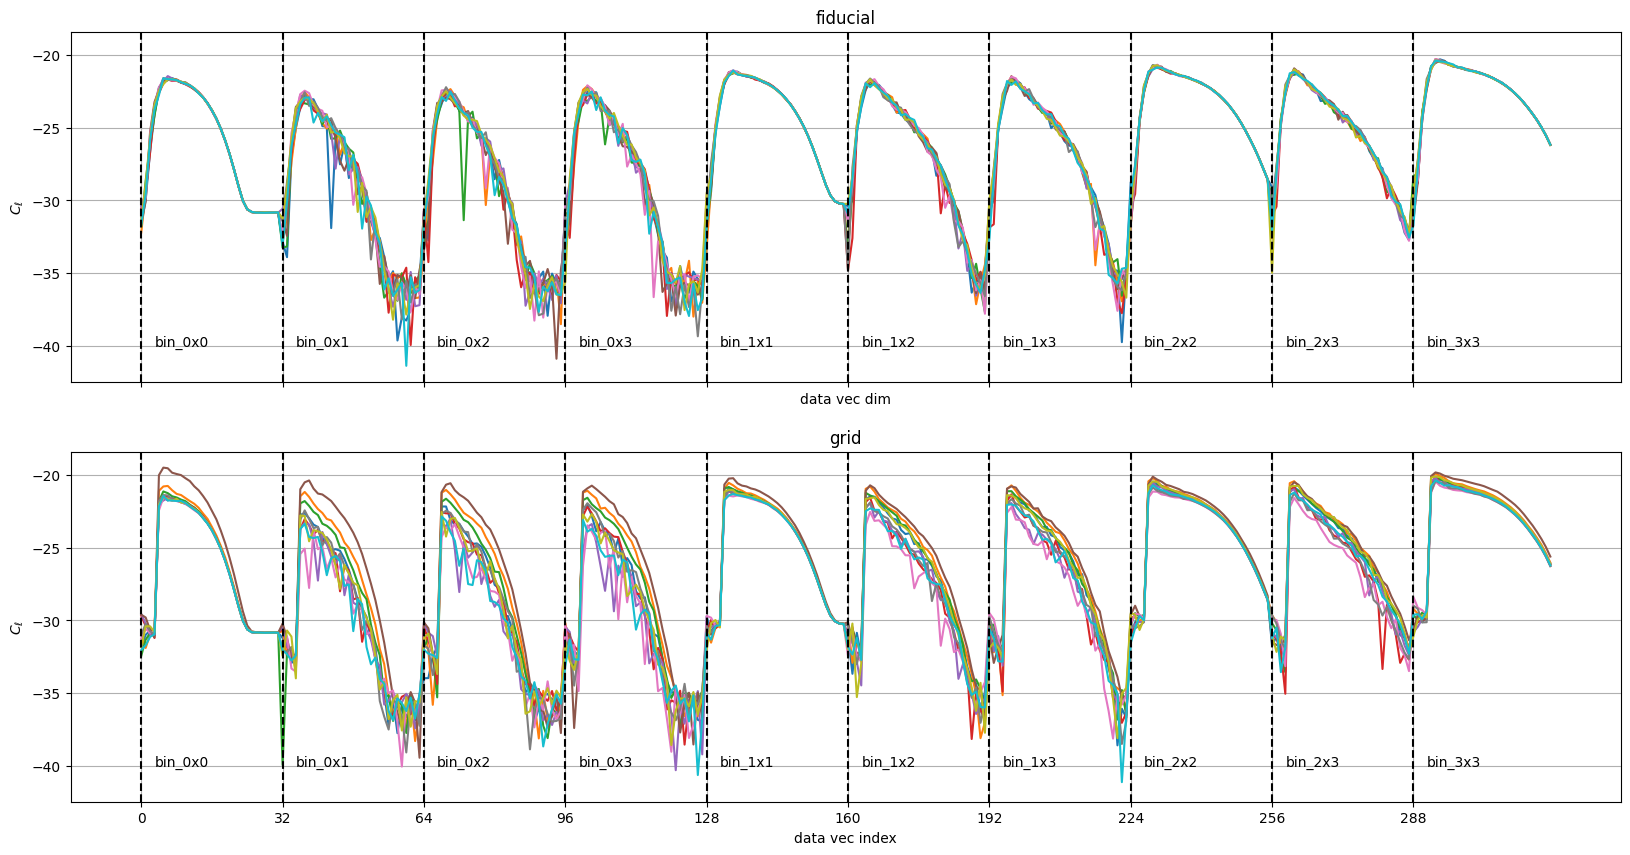

In [23]:
cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_gaussian_noise=True,
    # bin_indices=[bin_index],
    # dset
    batch_size=batch_size,
    shuffle_buffer=shuffle_buffer,
    # smoothing not from the dlss_conf
    # theta_fwhms=theta_fwhm,
    # white_noise_sigmas=white_noise_sigma,
    # cls_from_maps=True,
    # preprocessing
    apply_log=apply_log,
    standardize=standardize,
)

In [45]:
import pickle as pkl
with open('/pscratch/sd/j/jbucko/DESY3/v13/lensing_cls/dataset_get_binned_power_spectra_dset.pkl','wb') as f:
    pkl.dump(out_dict,f)

In [24]:
type(out_dict)

dict

# hard cut dset

In [26]:
# l_mins = 8 * [30]
# l_maxs = [786, 1150, 1535, 1535, 267, 390, 509, 610]

# # def angle_to_ell(angles):
# #     return list(scales.angle_to_ell(np.array(angles), arcmin=True))
# # l_maxs = angle_to_ell([22.1, 15.1, 11.2, 9.4] + [65.1, 44.5, 34.1, 28.5])

# cl_dset_train, cl_dset_test, out_dict, scaler, pca = dataset.get_binned_power_spectra_dset_legacy(
#     base_dir, 
#     # configuration
#     msfm_conf=msfm_conf, 
#     dlss_conf=dlss_conf,
#     params=params,
#     # selection
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     # dset
#     batch_size=batch_size,
#     shuffle_buffer=shuffle_buffer,
#     # power spectra
#     l_mins=l_mins,
#     l_maxs=l_maxs,
#     # n_bins=n_bins,
#     fixed_binning=False,
#     # additional preprocessing
#     apply_log=apply_log,
#     standardize=standardize,
# )

In [27]:
# fig, ax = plt.subplots()

# steps = 3
# for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(steps)), total=steps):
#     ax.plot(cl_batch[0])

# ax.set(xlabel=r"$\ell$", ylabel=r"$C_\ell$")

# functions and global constants

In [25]:
n_cls = out_dict["grid/cls/train"].shape[-1]
n_params = len(params)
n_summary = n_params

num_hidden_units = 1024
num_layers = 2

# num_hidden_units = 256
# num_layers = 4

dropout_rate = 0.1

def get_cl_summary_network(n_summary=n_summary):
    mlp = MultiLayerPerceptron(
        output_size=n_summary, 
        num_hidden_units=num_hidden_units, 
        num_layers=num_layers, 
        dropout_rate=dropout_rate
    )
    mlp.build((None, n_cls))
    
    return mlp

In [29]:
def train_model(model, eval_every=None):
    do_validation = eval_every is not None
    
    train_losses = []
    train_steps = []
    vali_steps = []
    vali_losses = []
    for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(n_steps+1)), total=n_steps):
        train_losses.append(model.grid_train_step(cl_batch, cosmo_batch))
        train_steps.append(i)
        
        if do_validation and (i % eval_every == 0) and (i !=0):
            vali_loss = []
            for cl_batch, cosmo_batch in cl_dset_test:
                vali_loss.append(model.vali_loss_fn(model(cl_batch, training=False), cosmo_batch))
            vali_losses.append(np.mean(vali_loss))
            vali_steps.append(i)

    fig, ax = plt.subplots()
    ax.plot(train_steps[100:], train_losses[100:], label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend()
    
    if do_validation:
        print(f"final validation loss = {vali_losses[-1]}")
        
    model.save_model()

# variational lower bound

In [28]:
learning_rate = 1e-4

summary_net = get_cl_summary_network()

if cosine_decay:
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=learning_rate, decay_steps=n_steps, alpha=0.0
    )
    # optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    tf.keras.optimizers.legacy.Adam
else:
    optimizer = tf.keras.optimizers.Adam(learning_rate)
    
model = GridLossModel(
    summary_net,
    n_side=None,
    indices=None,
    optimizer=optimizer,
    checkpoint_dir=os.path.join(out_dir, "model"),
    restore_checkpoint=True,
)

model.setup_grid_loss_step(
    batch_size=batch_size,
    dim_theta=n_params,
    loss="mutual_info",
    dim_x=n_cls,
    dim_summary=n_summary,
    mutual_info_estimator="variational",
    clip_by_global_norm=1.0,
    mutual_info_kwargs={"full_covariance": False},
)

25-04-03 03:01:57 base_model.p INF   Initializing with a normal Sequential model 


ValueError: You are trying to restore a checkpoint from a legacy Keras optimizer into a v2.11+ Optimizer, which can cause errors. Please update the optimizer referenced in your code to be an instance of `tf.keras.optimizers.legacy.Optimizer`, e.g.: `tf.keras.optimizers.legacy.Adam`.

In [39]:
# train_model(model, eval_every=n_steps//10)
# n_steps = 200_000

# save the results

In [32]:
fidu_preds = model(out_dict["fidu/cls"])
grid_preds = model(out_dict["grid/cls/test"])

pred_file = os.path.join(out_dir, "preds.h5")
with h5py.File(pred_file, "w") as f:
    f.create_dataset(name="grid/preds/test", data=grid_preds)
    f.create_dataset(name="grid/cosmos/test", data=out_dict["grid/cosmos/test"])
    f.create_dataset(name="fidu/preds", data=fidu_preds)

print(f"Wrote to {pred_file}\n")
print(fidu_preds)

Wrote to /pscratch/sd/a/athomsen/run_files/v13/cls/mutual_info/lensing=True,clustering=False,standard=False,log=True,cosine=False,steps=200000/8mpc/preds.h5

tf.Tensor(
[[ 0.38762775 -0.5874963  -0.478207    0.3110926  -0.31009448  0.04636277]
 [ 0.4030678  -0.5120814  -0.460909    0.26990858 -0.3085463   0.14833671]
 [ 0.39634138 -0.4869082  -0.46564922  0.17525601 -0.3563466   0.16051593]
 ...
 [ 0.4204548  -0.67044556 -0.5852138   0.404603   -0.38696423  0.06430431]
 [ 0.43244153 -0.5152898  -0.4911998   0.37861562 -0.3915368   0.21005246]
 [ 0.36244336 -0.6257293  -0.485476    0.37458912 -0.31510788  0.03358788]], shape=(35920, 6), dtype=float32)


### addtional internal mocks

In [33]:
# clustering_file = "/pscratch/sd/j/jbucko/DESY3/v13/linear_bias/clustering/maps/maps_for_compression_v13_clustering_True_lensing_False_grid_cosmo.pkl"
# with open(clustering_file, 'rb') as f:
#     jozef_maps = pickle.load(f)

# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# for i in range(jozef_maps.shape[0]):
#     for j in range(jozef_maps.shape[1]):
#         gc_map = jozef_maps[i,j]
        
#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             msfm_conf=msfm_conf,
#             dlss_conf=dlss_conf,
#             base_dir=base_dir,
#             from_raw_cls=False,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=with_cross_z,
#             with_cross_probe=(with_lensing and with_clustering),
#             # bin_indices=[bin_index],
#             # additional preprocessing
#             apply_log=apply_log,
#             # standardize=standardize,
#             # scaler=scaler,
#             # pca_components=None,
#             # pca=pca,
#         )
        
#         print(obs_cl.shape)
        

In [34]:
# import pickle

# lensing_file = "/pscratch/sd/j/jbucko/DESY3/v13/linear_bias/lensing/maps/maps_for_compression_v13_clustering_False_lensing_True_grid_cosmo.pkl"
# with open(lensing_file, 'rb') as f:
#     data = pickle.load(f)

# print(data.shape)

In [35]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# with h5py.File(pred_file, "a") as f_out:
#     for obs_label in mocks:
#         obs_file = f"/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_mock_observation_{obs_label}.h5"

#         with h5py.File(obs_file, "r") as f_in:
#             gc_map = []
#             for i in range(1,5):
#                 gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
#             gc_map = np.stack(gc_map, axis=-1)

#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             msfm_conf=msfm_conf,
#             dlss_conf=dlss_conf,
#             base_dir=base_dir,
#             from_raw_cls=False,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=with_cross_z,
#             with_cross_probe=(with_lensing and with_clustering),
#             # bin_indices=[bin_index],
#             # additional preprocessing
#             apply_log=apply_log,
#             # standardize=standardize,
#             # scaler=scaler,
#             # pca_components=None,
#             # pca=pca,
#         )
        
#         fig, ax = plt.subplots()
#         ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
#         ax.plot(np.squeeze(obs_cl), label=obs_label, alpha=0.5)
#         ax.legend(loc="best")
#         ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$", title=obs_label)

#         obs_pred = model(obs_cl)
#         print("\n", obs_label, obs_pred, "\n")
            
#         f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)


# external mocks

### clustering

In [36]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# with h5py.File(pred_file, "a") as f_out:
#     for obs_label in mocks:
#         obs_file = f"/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_mock_observation_{obs_label}.h5"

#         with h5py.File(obs_file, "r") as f_in:
#             gc_map = []
#             for i in range(1,5):
#                 gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
#             gc_map = np.stack(gc_map, axis=-1)

#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             msfm_conf=msfm_conf,
#             dlss_conf=dlss_conf,
#             base_dir=base_dir,
#             from_raw_cls=False,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=with_cross_z,
#             with_cross_probe=(with_lensing and with_clustering),
#             # bin_indices=[bin_index],
#             # additional preprocessing
#             apply_log=apply_log,
#             # standardize=standardize,
#             # scaler=scaler,
#             # pca_components=None,
#             # pca=pca,
#         )
        
#         fig, ax = plt.subplots()
#         ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
#         ax.plot(np.squeeze(obs_cl), label=obs_label, alpha=0.5)
#         ax.legend(loc="best")
#         ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$", title=obs_label)

#         obs_pred = model(obs_cl)
#         print("\n", obs_label, obs_pred, "\n")
            
#         f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)


### Buzzard flock

In [37]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# buzzard_flock_files = os.listdir(buzzard_flock_dir)

# with h5py.File(pred_file, "a") as f_out:
#     for buzzard_flock_file in buzzard_flock_files:
#         obs_file = os.path.join(buzzard_flock_dir, buzzard_flock_file)
#         obs_label = buzzard_flock_file[23:-3]
    
#         with h5py.File(obs_file, "r") as f_in:
#             gc_map = []
#             for i in range(1,5):
#                 gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
#             gc_map = np.stack(gc_map, axis=-1)

#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             msfm_conf=msfm_conf,
#             dlss_conf=dlss_conf,
#             base_dir=base_dir,
#             from_raw_cls=False,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=with_cross_z,
#             with_cross_probe=(with_lensing and with_clustering),
#             # bin_indices=[bin_index],
#             # additional preprocessing
#             apply_log=apply_log,
#             # standardize=standardize,
#             # scaler=scaler,
#             # pca_components=None,
#             # pca=pca,
#         )
        
#         fig, ax = plt.subplots()
#         ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
#         ax.plot(np.squeeze(obs_cl), label=obs_label, alpha=0.5)
#         ax.legend(loc="best")
#         ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$", title=obs_label)

#         obs_pred = model(obs_cl)
#         print("\n", obs_label, obs_pred, "\n")
            
#         # f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)

#         out_label = f"mocks/pred/{obs_label}" 
#         if out_label in f_out:
#             del f_out[out_label]
#         f_out.create_dataset(name=out_label, data=obs_pred)



### lensing

### single Buzzard

25-04-01 03:34:40     files.py INF   Loaded the pixel file /global/u1/j/jbucko/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
25-04-01 03:34:40 configuratio INF   Loaded the config 
25-04-01 03:34:40 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  94.82001756
 138.81748072 181.20805369 216.43286573] from the dlss config 
25-04-01 03:34:40 preprocessin INF   Using l_mins = [0 0 0 0 0 0 0 0] by default (no smoothing) 
25-04-01 03:34:40     files.py INF   Loaded the pixel file /global/u1/j/jbucko/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
25-04-01 03:34:40     files.py INF   Loaded the pixel file /global/u1/j/jbucko/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
25-04-01 03:34:41     files.py INF   Loaded the pixel file /global/u1/j/jbucko/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
25-04-01 03:34:42     files.py INF   Loaded the pi

NameError: name 'model' is not defined

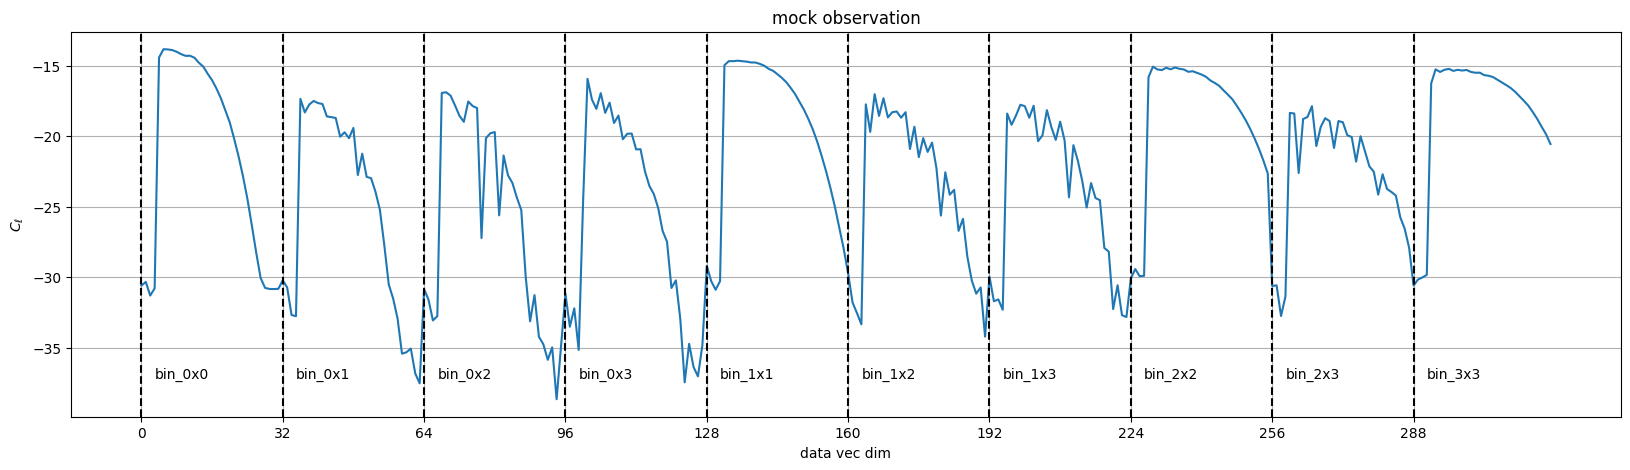

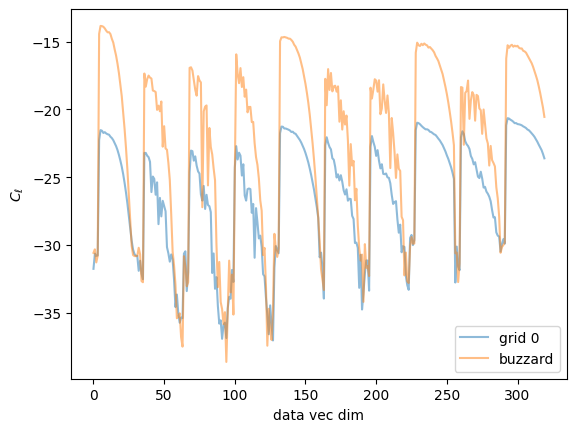

In [16]:
obs_label = "Buzzard"

# single Buzzard, not flock

n_side = msfm_conf["analysis"]["n_side"]
n_pix = msfm_conf["analysis"]["n_pix"]
data_vec_pix = files.load_pixel_file(msfm_conf)[0]
hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_from_g1g2.h5"
# buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_weights_with_balrog_e12_shear_with_buzzard_e1e2.h5"
# buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_e1e2_from_DES_g1g2_from_Buzzard.h5"
# buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_e1e2_from_DES_g1g2_from_Buzzard_with_weights.h5"
# buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_shape_noise_fw_g1g2_Buzzard.h5"
# buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_shape_noise_fw_g1g2_Buzzard_shape_noise_from_cosmogrid.h5"
buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_shape_noise_fw_g1g2_Buzzard_shape_noise_from_cosmogrid_no_true_shear.h5"




with h5py.File(buzzard_lensing_file, "r") as f_in:
    gamma1 = []
    gamma2 = []
    for i in range(1,5):
        gamma1.append(f_in[f"metacal/raw_gamma1_bin{i}"])
        gamma2.append(f_in[f"metacal/raw_gamma2_bin{i}"])
    gamma1 = np.stack(gamma1, axis=-1)
    gamma2 = np.stack(gamma2, axis=-1)
    
    wl_map = np.stack([gamma1, gamma2], axis=-1)

wl_map = np.where(wl_map < -10, 0.0, wl_map)

obs_cl = preprocessing.get_preprocessed_cl_observation(
    wl_gamma_map=wl_map,
    gc_count_map=np.zeros((n_pix,4)),
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    base_dir=base_dir,
    # nest_in=True,
    # nest_in=False,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_cross_probe=(with_lensing and with_clustering),
    # bin_indices=[bin_index],
    # additional preprocessing
    apply_log=apply_log,
    standardize=standardize,
    # scaler=scaler,
    # pca_components=None,
    # pca=pca,
)

# with h5py.File(buzzard_lensing_file, "r") as f_in:
#     kappa = []
#     for i in range(1,5):
#         kappa.append(f_in[f"metacal/kappa_forward_modelled_bin{i}"])
#     kappa = np.stack(kappa, axis=-1)



# obs_cl = preprocessing.get_preprocessed_cl_observation(
#     obs_cl=obs_cl,
#     # configuration
#     msfm_conf=msfm_conf,
#     dlss_conf=dlss_conf,
#     base_dir=base_dir,
#     # nest_in=True,
#     nest_in=False,
#     # selection
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     with_cross_z=with_cross_z,
#     with_cross_probe=(with_lensing and with_clustering),
#     # bin_indices=[bin_index],
#     # additional preprocessing
#     apply_log=apply_log,
#     standardize=standardize,
#     # scaler=scaler,
#     # pca_components=None,
#     # pca=pca,
# )


fig, ax = plt.subplots()
# ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
ax.plot(out_dict["grid/cls/test"][0,:], label="grid 0", alpha=0.5)
ax.plot(np.squeeze(obs_cl), label="buzzard", alpha=0.5)
ax.legend(loc="best")
ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$")

obs_pred = model(obs_cl)
print("\n", obs_label, obs_pred, "\n")

with h5py.File(pred_file, "a") as f_out:
    out_label = f"mocks/pred/{obs_label}" 
    if out_label in f_out:
        del f_out[out_label]
    f_out.create_dataset(name=out_label, data=obs_pred)


In [39]:
 # Buzzard tf.Tensor([[ 0.7041886  -0.43355274 -1.7022698   0.45138672 -0.57715696  0.31233233]], shape=(1, 6), dtype=float32) 

In [40]:
cl_dset_train.sahape

AttributeError: 'PrefetchDataset' object has no attribute 'sahape'

In [ ]:
out_dict["grid/cls/train"].shape

In [ ]:
fig, ax = plt.subplots()
# ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
ax.plot(out_dict["grid/cls/test"][0,:], label="grid 0", alpha=0.5)
ax.plot(np.squeeze(obs_cl), label="buzzard", alpha=0.5)
ax.legend(loc="best")
ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$")

In [ ]:
from msfm.utils import cross_statistics

grid_summs = out_dict["grid/cls/test"]

_, bin_names = cross_statistics.get_cross_bin_indices(
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=True,
    with_cross_probe=False,
)

fig, ax = plt.subplots(figsize=(10, 5), sharex=True, sharey=True)

# grid
random_indices = np.random.choice(np.arange(grid_summs.shape[0]), 100)

for i in random_indices:
    ax.plot(grid_summs[i], alpha=0.3)

ax.set(title="grid", xlabel="data vec index", ylabel=r"$C_\ell$")
ax.grid(True)

ax.plot(np.squeeze(obs_cl), label="buzzard", color="k")

# cosmetics
bin_size = 32
if bin_size is not None:
    x = 0
    ticks = []
    for i, x in enumerate(np.arange(0, len(bin_names) * bin_size, bin_size)):
        ax.axvline(x, color="k", linestyle="--")

        ax.text(x + 3, 0.1, bin_names[i], transform=ax.get_xaxis_transform())

        ticks.append(x)

    ax.set_xticks(ticks)

ax.legend()

In [ ]:
with h5py.File(buzzard_lensing_file, "r") as f_in:
    print(f_in["metacal"].keys())

In [ ]:
buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_e1e2_from_DES_g1g2_from_Buzzard_with_weights.h5"
# buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_shape_noise_fw_g1g2_Buzzard.h5"

In [ ]:
with h5py.File(buzzard_lensing_file, "r") as f_in:
    kappa = []
    for i in range(1,5):
        kappa.append(f_in[f"metacal/kappa_forward_modelled_bin{i}"])
    kappa = np.stack(kappa, axis=-1)

hp.mollview(kappa[:,0], nest=True)

In [ ]:
with h5py.File(buzzard_lensing_file, "r") as f_in:
    gamma1 = []
    for i in range(1,5):
        gamma1.append(f_in[f"metacal/raw_gamma1_bin{i}"])
    gamma1 = np.stack(gamma1, axis=-1)

hp.mollview(gamma1[:,0], nest=False)

In [ ]:
buzzard_lensing_file = "/pscratch/sd/j/jbucko/DESY3/mock_observations/lensing/buzzard_flock/0/DESY3_mock_observation_buzzard_0_from_g1g2.h5"

from msfm.utils import observation

with h5py.File(buzzard_lensing_file, "r") as f_in:
    gamma1 = []
    gamma2 = []
    for i in range(1,5):
        gamma1.append(f_in[f"metacal/raw_gamma1_bin{i}"])
        gamma2.append(f_in[f"metacal/raw_gamma2_bin{i}"])
    gamma1 = np.stack(gamma1, axis=-1)
    gamma2 = np.stack(gamma2, axis=-1)
    
    wl_map = np.stack([gamma1, gamma2], axis=-1)

# observation, observation_cls, data_vec_pix = observation.forward_model_observation_map(
#     wl_gamma_map=wl_map,
#     conf=msfm_conf,
#     apply_norm=False,
#     with_padding=True,
#     nest_in=True,
# )

obs_cl = preprocessing.get_preprocessed_cl_observation(
    wl_gamma_map=wl_map,
    gc_count_map=np.zeros((n_pix,4)),
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    base_dir=base_dir,
    # nest_in=True,
    nest_in=False,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_cross_probe=(with_lensing and with_clustering),
    # bin_indices=[bin_index],
    # additional preprocessing
    apply_log=apply_log,
    standardize=standardize,
    # scaler=scaler,
    # pca_components=None,
    # pca=pca,
)

obs_map = np.zeros((n_pix,observation.shape[-1]))
obs_map[data_vec_pix] = observation

hp.mollview(obs_map[:,0], nest=True)

In [ ]:
out_dict["grid/cls/train"].shape

In [ ]:
fig, ax = plt.subplots()
ax.plot(observation_cls[:,0], label="fiducial", alpha=0.5)
ax.set(yscale="log")

In [ ]:
fig, ax = plt.subplots()
# ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
ax.plot(out_dict["grid/cls/test"][0,:], label="grid 0", alpha=0.5)
ax.plot(np.squeeze(obs_cl), label="buzzard (noiseless)", alpha=0.5)
ax.legend(loc="best")
ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$")


# old

In [ ]:
# file_dict = input_output.load_human_summaries(
#     "/pscratch/sd/a/athomsen/v11desy3/v12/nonlinear",
#     "cls",
#     file_label=None,
#     return_raw_cls=False,
#     return_fiducial=False,
#     return_grid=True,
#     cls_from_maps=False,
# )

# cosmo = file_dict["grid/cosmo"]
# print(cosmo.shape)

In [ ]:
# pca_components = 32

# grid_pca, scaler, pca = preprocessing.preprocess_human_summaries(
#     out_dict["grid/cls/test"], apply_log, standardize=False, pca_components=pca_components
# )
# # fidu_summs, _, _ = preprocess_human_summaries(
# #     fidu_summs, apply_log, standardize=standardize, pca_components=pca_components, scaler=scaler, pca=pca
# # )


In [ ]:
# fidu_ex = out_dict["fidu/cls"][0,:]
# mock_ex = np.squeeze(obs_cl)

# fig, ax = plt.subplots()

# ax.plot(fidu_ex, label="fiducial", alpha=0.5)
# ax.plot(mock_ex, label="mock", alpha=0.5)

# ax.legend(loc="best")
# # ax.set(yscale="log")

### constant learning rate, gradient clipping

In [ ]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-3)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": False}
# )

# train_model(model, do_validation=True)

In [ ]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-4)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": False}
# )

# train_model(model, do_validation=True)
# cosine_schedule = False

In [ ]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-3)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": True}
# )

# train_model(model, do_validation=True)
# cosine_schedule = False

### constant learning rate, no gradient clipping

In [ ]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-3)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=None,
#     mutual_info_kwargs={"full_covariance": True}
# )

# train_model(model, do_validation=True)
# cosine_schedule = False

### cosine decay

In [ ]:
# summary_net = get_cl_summary_network()

# lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
#     initial_learning_rate=1e-3, decay_steps=n_steps, alpha=0.0
# )
# optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": False}
# )

# train_model(model, do_validation=True)
# cosine_schedule = True

In [ ]:
# summary_net = get_cl_summary_network()

# lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
#     initial_learning_rate=1e-3, decay_steps=n_steps, alpha=0.0
# )
# optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": True}
# )

# train_model(model, do_validation=True)
# cosine_schedule = True

# save results

In [ ]:
# fidu_preds = model(out_dict["fidu/cls"])
# grid_preds = model(out_dict["grid/cls/test"])

# # pred_file = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},steps={n_steps}/preds.h5")
# pred_file = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_schedule},steps={n_steps}/preds.h5")
# # pred_file = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},steps={n_steps}/preds.h5")
# os.makedirs(os.path.dirname(pred_file), exist_ok=True)

# with h5py.File(pred_file, "w") as f:
#     f.create_dataset(name="grid/preds/test", data=grid_preds)
#     f.create_dataset(name="grid/cosmos/test", data=out_dict["grid/cosmos/test"])
#     f.create_dataset(name="fidu/preds", data=fidu_preds)
    
# print(f"Wrote to {pred_file}")

In [ ]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# with h5py.File(pred_file, "a") as f_out:
#     for obs_label in mocks:
#         obs_file = f"/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_mock_observation_{obs_label}.h5"

#         with h5py.File(obs_file, "r") as f_in:
#             gc_map = []
#             for i in range(1,5):
#                 gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
#             gc_map = np.stack(gc_map, axis=-1)

#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             conf=msfm_conf,
#             from_raw_cls=True,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=True,
#             with_cross_probe=(with_lensing and with_clustering),
#             # CLs scale cuts
#             l_mins=l_mins,
#             l_maxs=l_maxs,
#             n_bins=n_bins,
#             # additional preprocessing
#             apply_log=apply_log,
#             standardize=standardize,
#             scaler=scaler,
#             pca_components=None,
#             pca=pca,
#         )
        
#         obs_pred = model(obs_cl)
#         print("\n", obs_label, obs_pred, "\n")
            
#         f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)
